In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:

import numpy as np
import pandas as pd

np.random.seed(42)

n = 5000

soc = np.random.uniform(10, 100, n)
soh = np.random.uniform(70, 100, n)
temperature = np.random.uniform(-5, 40, n)
speed = np.random.uniform(20, 110, n)
traffic = np.random.uniform(0, 1, n)
slope = np.random.uniform(-5, 8, n)
hvac = np.random.uniform(0, 1, n)
driving_style = np.random.uniform(0, 1, n)

battery_energy = 60 * (soh / 100) * (soc / 100)

consumption = (
    14
    + 0.035 * (speed - 50)
    + 3 * traffic
    + 0.35 * np.maximum(slope, 0)
    + 2 * hvac
    + 0.04 * np.abs(temperature - 20)
    + 3 * driving_style
)

actual_range = (battery_energy / consumption) * 100
actual_range += np.random.normal(0, 3, n)
actual_range = np.maximum(actual_range, 0)

data = pd.DataFrame({
    "SOC": soc,
    "SOH": soh,
    "Temperature": temperature,
    "Speed": speed,
    "Traffic": traffic,
    "Slope": slope,
    "HVAC": hvac,
    "Driving_Style": driving_style,
    "Actual_Range": actual_range
})

data.head()

,SOC,SOH,Temperature,Speed,Traffic,Slope,HVAC,Driving_Style,Actual_Range
0,43.708611,81.809066,11.813837,64.970322,0.729998,-3.799179,0.638145,0.609393,104.794990
1,95.564288,84.203070,9.981044,87.207210,0.184512,-4.210202,0.459292,0.038903,278.367418
2,75.879455,95.636422,2.926926,70.640010,0.346640,2.854495,0.964499,0.612260,204.774259
3,63.879264,80.200132,22.327000,27.497232,0.663281,7.559512,0.218978,0.089669,164.238653
4,24.041678,96.089491,16.448087,36.702221,0.482089,1.535377,0.587856,0.710344,71.144177


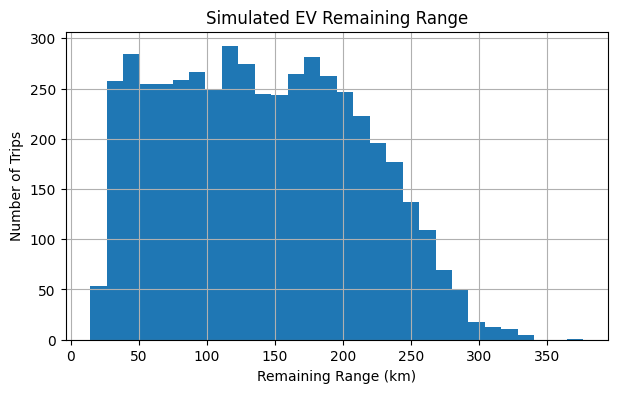

In [3]:

plt.figure(figsize=(7, 4))

plt.hist(data["Actual_Range"], bins=30)

plt.xlabel("Remaining Range (km)")
plt.ylabel("Number of Trips")
plt.title("Simulated EV Remaining Range")

plt.grid(True)
plt.show()

In [4]:

features = [
    "SOC", "SOH", "Temperature", "Speed",
    "Traffic", "Slope", "HVAC", "Driving_Style"
]

X = data[features]
y = data["Actual_Range"]

# Keep 20% for final testing
X_train_cal, X_test, y_train_cal, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Split remaining 80% into training and calibration
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_cal, y_train_cal, test_size=0.25, random_state=42
)

print("Training trips:", len(X_train))
print("Calibration trips:", len(X_cal))
print("Testing trips:", len(X_test))

Training trips: 3000
Calibration trips: 1000
Testing trips: 1000


In [5]:

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    min_samples_leaf=2,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [6]:

# Predict range for calibration trips
cal_predictions = model.predict(X_cal)

# Calculate absolute prediction errors
cal_errors = np.abs(y_cal - cal_predictions)

# Set desired coverage to 90%
confidence = 0.90
n_cal = len(cal_errors)

# Calculate conformal calibration threshold
rank = min(
    int(np.ceil((n_cal + 1) * confidence)),
    n_cal
)

q = np.sort(cal_errors)[rank - 1]

print("90% interval margin:", round(q, 2), "km")

90% interval margin: 14.5 km


In [7]:

# Predict range for unseen test trips
predictions = model.predict(X_test)

# Calculate lower and upper bounds
lower = np.maximum(0, predictions - q)
upper = predictions + q

# Check actual range inside the interval
inside = (y_test >= lower) & (y_test <= upper)

# Calculate evaluation metrics
coverage = inside.mean() * 100

average_error = np.mean(np.abs(y_test - predictions))

average_percentage_error = np.mean(
    np.abs(y_test - predictions) / y_test
) * 100

average_width = np.mean(upper - lower)

print("Test coverage:", round(coverage, 2), "%")
print("Average absolute error:", round(average_error, 2), "km")
print("Average percentage error:", round(average_percentage_error, 2), "%")
print("Average interval width:", round(average_width, 2), "km")

Test coverage: 90.4 %
Average absolute error: 6.72 km
Average percentage error: 5.51 %
Average interval width: 28.99 km


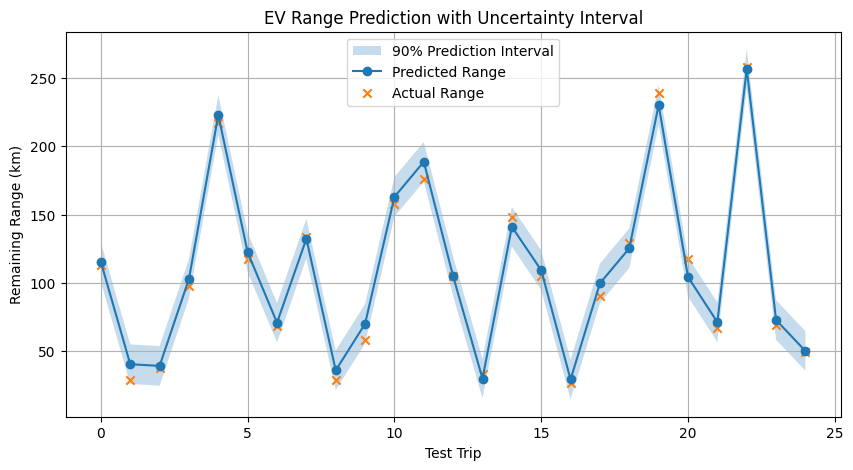

In [8]:

count = 25
x_axis = np.arange(count)

plt.figure(figsize=(10, 5))

plt.fill_between(
    x_axis, lower[:count], upper[:count],
    alpha=0.25, label="90% Prediction Interval"
)

plt.plot(
    x_axis, predictions[:count],
    marker="o", label="Predicted Range"
)

plt.scatter(
    x_axis, y_test.iloc[:count],
    marker="x", label="Actual Range"
)

plt.xlabel("Test Trip")
plt.ylabel("Remaining Range (km)")
plt.title("EV Range Prediction with Uncertainty Interval")
plt.legend()
plt.grid(True)
plt.show()